## Day 9 — Linear Algebra II: Matrices and Transformations ·

## Part A — the curriculum activities

## TASK 01__Visualise the four transformations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#Shape: a unit square
# Each column represents one (x,y) points
shape = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
], dtype=float)

# ROtation matrix
def rotation(degrees):
    angle = np.radians(degrees)

    return np.array([
        [np.cos(angle),-np.sin(angle)],
        [np.sin(angle), np.cos(angle)]
    ])


# Show original and transformed shape
def show_transform(transform_matrix):
    transformed_shape = transform_matrix @ shape

    plt.figure(figsize= (8, 4))

    # Original shape
    plt.subplot(1, 2, 1)
    plt.plot(shape[0], shape[1], marker="o")
    plt.title("original Shape")
    plt.axis("equal")
    plt.grid(True)

    # Transformed shape
    plt.subplot(1, 2, 2)
    plt.plot(transformed_shape[0], transformed_shape[1], marker="o")
    plt.title("Transformed Shape")
    plt.axis("equal")
    plt.grid(True)

    plt.show()


# 1. Scaling

scaling_matrix = np.array([
    [2, 0],
    [0, 0.5]
])

show_transform(scaling_matrix)

# x-axis stretches by 2 times.
# y-axis shrinks to half its original size



# Rotation

show_transform(rotation(30))
show_transform(rotation(90))
show_transform(rotation(180))

# 30°, 90°, and 180° rotate the shape around the origin.
# The shape's size and distances between points stay unchanged.


#3. Shear

shear_matrix = np.array([
    [1, 1],
    [0, 1]
])

show_transform(shear_matrix)

#The x-coordinate changes according to y.
# The square become a parallelogram.


# 4. Reflection across x-axis

reflection_x = np.array([
    [1, 0],
    [0, -1]
])

show_transform(reflection_x)

# The shape flips vertically across the x-axis.
# Points on the x-axis stay fixed.


# 5. Reflection across y-axis

reflection_y = np.array([
    [-1, 0],
    [0, 1]
])

show_transform(reflection_y)

# The shape flips horizontally across the y-axis.
# Points on the y-axis stay fixed.


Q1. Why is each point stored as a column, not a row? What breaks if you use rows?

**Answer:** Columns allow us to apply the transformation matrix directly to all points using `matrix @ shape`. With rows, the matrix dimensions/order would need to change.

Q2. In the rotation matrix, which entries would you change to rotate clockwise instead?

**Answer:** Change the signs of the two sine terms.

Q3. What single change to a scaling matrix turns it into a reflection?

**Answer:** Change one scaling value to `-1`, which flips the shape across an axis.


## TASK 02__Compute determinants and check invertibility

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the original shape

shape = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
], dtype=float)



# 2. Create the four transformation matrices

# Scaling: x is doubled, y is reduced to half
scaling_matrix = np.array([
    [2, 0],
    [0, 0.5]
])


# Rotation by 30 degrees
angle = np.radians(30)

rotation_matrix = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle),  np.cos(angle)]
])


# Shear in the x-direction
shear_matrix = np.array([
    [1, 1],
    [0, 1]
])


# Reflection across the x-axis
reflection_matrix = np.array([
    [1, 0],
    [0, -1]
])



# 3. Calculate determinant of each matrix

transformation_matrices = {
    "Scaling": scaling_matrix,
    "Rotation": rotation_matrix,
    "Shear": shear_matrix,
    "Reflection": reflection_matrix
}

for matrix_name, matrix in transformation_matrices.items():
    determinant = np.linalg.det(matrix)
    print(f"{matrix_name} determinant: {determinant:.2f}")




# 4. Create a singular matrix

# The second column is 2 times the first column.
# Therefore, the determinant is zero.
singular_matrix = np.array([
    [1.0, 2.0],
    [2.0, 4.0]
])


singular_determinant = np.linalg.det(singular_matrix)

print(f"\nSingular matrix determinant: {singular_determinant:.2f}")



# 5. Apply singular matrix to the shape

collapsed_shape = singular_matrix @ shape

plt.plot(
    collapsed_shape[0],
    collapsed_shape[1],
    marker="o"
)

plt.title("Shape After Singular Transformation")
plt.axis("equal")
plt.grid(True)
plt.show()

'''# The square collapses into a line because
# the transformation loses one dimension.
'''



# 6. Try to invert the singular matrix

try:
    inverse_matrix = np.linalg.inv(singular_matrix)
    print("Inverse matrix:")
    print(inverse_matrix)

except np.linalg.LinAlgError:
    print("Cannot invert the singular matrix.")




# 7. Check whether a matrix is invertible

def is_invertible(matrix):
    determinant = np.linalg.det(matrix)

    return not np.isclose(determinant, 0)



# 8. Test all five matrices

all_matrices = {
    "Scaling": scaling_matrix,
    "Rotation": rotation_matrix,
    "Shear": shear_matrix,
    "Reflection": reflection_matrix,
    "Singular": singular_matrix
}


for matrix_name, matrix in all_matrices.items():
    print(
        f"{matrix_name}: "
        f"{is_invertible(matrix)}"
    )


# A determinant of exactly zero means that the transformation
# loses information by collapsing one dimension. Therefore,
# the original shape cannot be recovered and the transformation
# cannot be undone.

Q1. Why check `np.isclose(det, 0)` instead of `det == 0`?

Because floating-point calculations can give a very small value instead of exact `0`. `np.isclose()` handles these small numerical errors.

Q2. What does a determinant of exactly 1 tell you about area? What does a negative determinant tell you about orientation?


* **det = 1:** Area remains unchanged.
* **det < 0:** Orientation is reversed (reflection occurs).

Q3. When the singular matrix hits your square, what shape is left, and why can't you get the square back?

The square becomes a **line (or a collapsed shape)** because one dimension is lost. You can't get it back because the singular matrix has **det = 0**, so it has no inverse.


## TASK 03__Verify associativity: (AB)C = A(BC)

Associative? True
Commutative? False


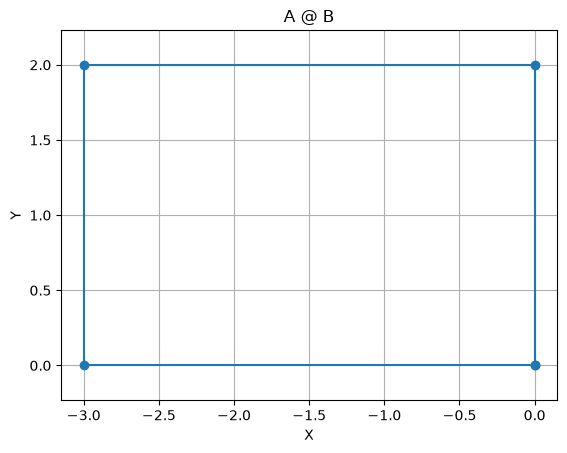

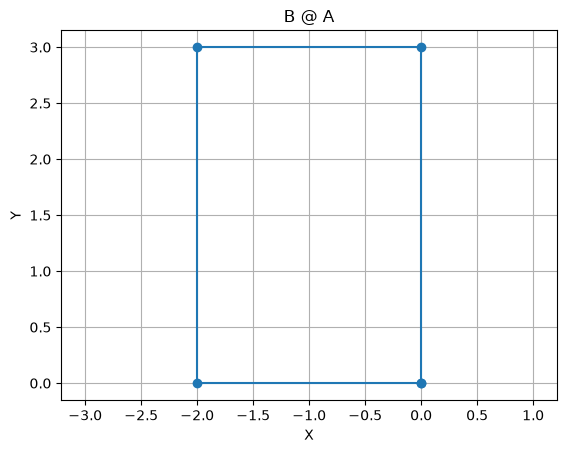

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Rotation matrix (90 degrees)
rotation_matrix = np.array([
    [0, -1],
    [1,  0]
])

# Scaling matrix
scaling_matrix = np.array([
    [2, 0],
    [0, 3]
])

# Shear matrix
shear_matrix = np.array([
    [1, 1],
    [0, 1]
])

# Check associativity
left_result = (rotation_matrix @ scaling_matrix) @ shear_matrix
right_result = rotation_matrix @ (scaling_matrix @ shear_matrix)

print("Associative?", np.allclose(left_result, right_result))

# Check commutativity
rotation_then_scaling = rotation_matrix @ scaling_matrix
scaling_then_rotation = scaling_matrix @ rotation_matrix

print("Commutative?", np.allclose(rotation_then_scaling, scaling_then_rotation))


# Shape: square
square = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
])

# Apply A @ B and B @ A
shape_rotation_scaling = rotation_then_scaling @ square
shape_scaling_rotation = scaling_then_rotation @ square

# Plot A @ B
plt.figure()
plt.plot(shape_rotation_scaling[0], shape_rotation_scaling[1], marker="o")
plt.title("A @ B")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid()
plt.show()

# Plot B @ A
plt.figure()
plt.plot(shape_scaling_rotation[0], shape_scaling_rotation[1], marker="o")
plt.title("B @ A")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid()
plt.show()

Q1. What is the difference between associativity and commutativity? Which does matrix multiplication have?

* **Associativity:** Grouping changes, but result stays same: `(A @ B) @ C = A @ (B @ C)`.
* **Commutativity:** Order changes, but result stays same: `A @ B = B @ A`.
* Matrix multiplication is **associative but generally not commutative**.

Q2. Why does the order of transformations matter geometrically? Give a real example.

Each transformation changes the shape before the next one acts. For example, **rotating then scaling** a shape can give a different result from **scaling then rotating**.

Q3. In `A @ B @ C` applied to a vector, which matrix acts on the vector first?

**C acts first**, then **B**, and finally **A**.
So: `A @ B @ C @ vector` → **C → B → A**.


## Part B — compose and apply

## TASK 04__Compose a sequence of transformations

Same result? True
Scaling determinant: 2.25
Rotation determinant: 1.0
Shear determinant: 1.0
Combined determinant: 2.250000000000001
Product of determinants: 2.25
Determinants match? True


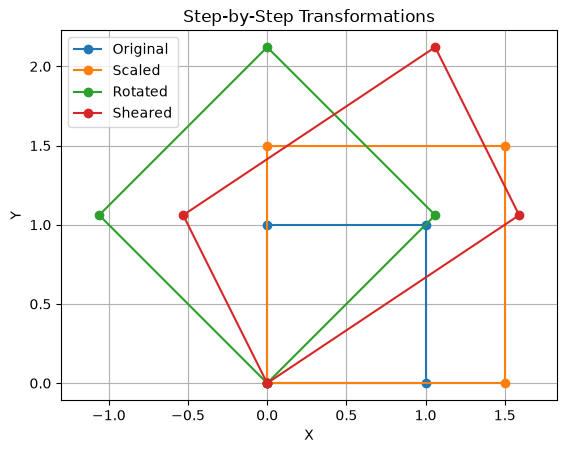

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Original square
original_shape = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
])

# 1. Scaling matrix
scaling_matrix = np.array([
    [1.5, 0],
    [0, 1.5]
])

# 2. Rotation matrix (45 degrees)
angle_radians = np.radians(45)

rotation_matrix = np.array([
    [np.cos(angle_radians), -np.sin(angle_radians)],
    [np.sin(angle_radians),  np.cos(angle_radians)]
])

# 3. Shear matrix
shear_matrix = np.array([
    [1, 0.5],
    [0, 1]
])

# Apply transformations separately
scaled_shape = scaling_matrix @ original_shape
rotated_shape = rotation_matrix @ scaled_shape
sheared_shape = shear_matrix @ rotated_shape

# Combine transformations
combined_matrix = shear_matrix @ rotation_matrix @ scaling_matrix

# Apply combined matrix in one step
combined_shape = combined_matrix @ original_shape

# Check both methods give the same result
print("Same result?",
    np.allclose(sheared_shape, combined_shape))

# Determinants
scaling_determinant = np.linalg.det(scaling_matrix)
rotation_determinant = np.linalg.det(rotation_matrix)
shear_determinant = np.linalg.det(shear_matrix)
combined_determinant = np.linalg.det(combined_matrix)

print("Scaling determinant:", scaling_determinant)
print("Rotation determinant:", rotation_determinant)
print("Shear determinant:", shear_determinant)
print("Combined determinant:", combined_determinant)

print("Product of determinants:",
      scaling_determinant * rotation_determinant * shear_determinant)

print("Determinants match?",
    np.isclose(
        combined_determinant,
          scaling_determinant * rotation_determinant * shear_determinant
    ))

# Plot each stage
plt.figure()

plt.plot(original_shape[0], original_shape[1], marker="o", label="Original")
plt.plot(scaled_shape[0], scaled_shape[1], marker="o", label="Scaled")
plt.plot(rotated_shape[0], rotated_shape[1], marker="o", label="Rotated")
plt.plot(sheared_shape[0], sheared_shape[1], marker="o", label="Sheared")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Step-by-Step Transformations")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

Q1. Why does the first-applied transformation sit on the RIGHT of the product?

Because matrix multiplication acts **from right to left**. So in `A @ B @ C`, **C acts first**, then B, then A.

Q2. Why does the determinant of a product equal the product of the determinants? What does that mean about area?

`det(A @ B) = det(A) × det(B)` because each transformation scales area by its determinant. Therefore, the combined area scaling is the **product of individual area scalings**.

Q3. If one matrix in the chain were singular, what would happen to the whole composition?

The whole composition would be **singular (`det = 0`)**. It would collapse at least one dimension, so the original shape **could not be recovered**.


## TASK 05__Special matrices and their properties

In [10]:
import numpy as np


# 1. Diagonal matrix - only scales
diagonal_matrix = np.array([
    [2.0, 0.0],
    [0.0, 3.0]
])

vector = np.array([1.0, 1.0])

scaled_vector = diagonal_matrix @ vector

print("Original vector:", vector)
print("After diagonal scaling:", scaled_vector)


# 2. Symmetric matrix
symmetric_matrix = np.array([
    [2.0, 1.0],
    [1.0, 3.0]
])

print("Symmetric?", np.allclose(
    symmetric_matrix,
    symmetric_matrix.T
))


# 3. Orthogonal matrix - rotation by 30 degrees
rotation_angle = np.radians(30)

orthogonal_matrix = np.array([
    [np.cos(rotation_angle), -np.sin(rotation_angle)],
    [np.sin(rotation_angle),  np.cos(rotation_angle)]
])

identity_matrix = np.eye(2)

print("Orthogonal?", np.allclose(
    orthogonal_matrix.T @ orthogonal_matrix,
    identity_matrix
))


# 4. Prove that length is preserved
original_vector = np.array([3.0, 4.0])

rotated_vector = orthogonal_matrix @ original_vector

original_length = np.linalg.norm(original_vector)
rotated_length = np.linalg.norm(rotated_vector)

print("Length kept?", np.isclose(
    rotated_length,
    original_length
))


# 5. Prove that angle is preserved
first_vector = np.array([1.0, 0.0])
second_vector = np.array([1.0, 1.0])


def calculate_angle(vector_a, vector_b):
    cosine_value = (
        vector_a @ vector_b
        / (np.linalg.norm(vector_a) * np.linalg.norm(vector_b))
    )

    cosine_value = np.clip(cosine_value, -1, 1)

    return np.degrees(np.arccos(cosine_value))


original_angle = calculate_angle(first_vector, second_vector)

rotated_first_vector = orthogonal_matrix @ first_vector
rotated_second_vector = orthogonal_matrix @ second_vector

rotated_angle = calculate_angle(
    rotated_first_vector,
    rotated_second_vector
)

print("Original angle:", original_angle)
print("After rotation:", rotated_angle)

print("Angle preserved?", np.isclose(
    original_angle,
    rotated_angle
))

Original vector: [1. 1.]
After diagonal scaling: [2. 3.]
Symmetric? True
Orthogonal? True
Length kept? True
Original angle: 45.00000000000001
After rotation: 45.00000000000001
Angle preserved? True


Q1. What makes a matrix orthogonal, in terms of its transpose and inverse?

A matrix is orthogonal when its **transpose equals its inverse**: `Q.T = Q⁻¹`. Equivalently, `Q.T @ Q = I`.

Q2. Why are rotations and reflections orthogonal, but shears and scalings are not?

Rotations and reflections **preserve lengths and angles**. Shears and scalings change lengths or angles, so they are not generally orthogonal.

Q3. Why might symmetric covariance matrices be useful?

Symmetry makes covariance relationships **consistent in both directions** and gives useful mathematical properties for analysis, such as **real eigenvalues and orthogonal eigenvectors**.


## Part C — put it together

## TASK 06__An interactive transformation explorer

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Original unit square
square_shape = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
], dtype=float)


def explore(top_left, top_right, bottom_left, bottom_right):
    # Create the 2x2 transformation matrix
    transformation_matrix = np.array([
        [top_left, top_right],
        [bottom_left, bottom_right]
    ], dtype=float)

    # Apply transformation to the square
    transformed_shape = transformation_matrix @ square_shape

    # Find where the two basis vectors land
    first_basis_destination = transformation_matrix[:, 0]
    second_basis_destination = transformation_matrix[:, 1]

    # Calculate determinant
    determinant_value = np.linalg.det(transformation_matrix)

    # Print information
    print("Transformation matrix:")
    print(transformation_matrix)

    print("First basis vector lands at:", first_basis_destination)
    print("Second basis vector lands at:", second_basis_destination)

    print("Determinant:", round(determinant_value, 2))

    # Create before/after plots
    plt.figure(figsize=(10, 4))

    # Original shape
    plt.subplot(1, 2, 1)
    plt.plot(square_shape[0], square_shape[1], marker="o")
    plt.title("Before Transformation")
    plt.axis("equal")
    plt.grid(True)

    # Transformed shape
    plt.subplot(1, 2, 2)
    plt.plot(transformed_shape[0], transformed_shape[1], marker="o")
    plt.title("After Transformation")
    plt.axis("equal")
    plt.grid(True)

    plt.show()


# 1. Pure rotation: 90 degrees
print("\n--- Pure Rotation ---")
explore(0, -1, 1, 0)


# 2. Pure scaling: x2 in both directions
print("\n--- Pure Scaling ---")
explore(2, 0, 0, 2)


# 3. Reflection across x-axis
print("\n--- Reflection ---")
explore(1, 0, 0, -1)


# 4. Negative determinant but normal-looking scaling
print("\n--- Negative Determinant Scaling ---")
explore(2, 0, 0, -2)


# 5. Collapse square to a line
print("\n--- Collapse to Line ---")
explore(1, 2, 2, 4)

Q1. Just by looking at the four numbers, can you predict the determinant before computing it?

Yes, sometimes. For a 2×2 matrix, if the cross-products look equal, the determinant will be **0**.

Q2. What do the two columns of the matrix tell you before you even plot anything?

They tell you **where the x-axis and y-axis basis vectors will move** after the transformation.

Q3. Which combinations of numbers always give a determinant of zero?

When the two columns are **linearly dependent**—one column is a multiple of the other.
Example: `[[1, 2], [2, 4]]` → determinant = **0**.
